# TEM v1 on Arena Replay Episodes

This notebook restores a checkpointed TEM v1 executor from the canonical arena training config, runs it on real processed Arena replay data, captures an evaluation trace, enriches that trace with arena world metadata, and renders the built-in TEM diagnostic figures.

The default checkpoint comes from the local TEM training log tree because this workspace does not contain a populated top-level `checkpoints/tem-v1/` mirror.


In [17]:
import sys
import tomllib
from pathlib import Path

import torch
from torch import device as Device

from ehc_sn.adapters.arena.tem import select_arena_tem_trace_fields
from ehc_sn.eval.contracts import EvaluationTraceRequest
from ehc_sn.figures import FigureContext, render
from ehc_sn.lightning.tem.tem_v1 import TEMV1ModelConfig, TEMV1TrainingModel
from ehc_sn.tasks.arena.providers import ArenaReplayProvider
from ehc_sn.tasks.arena.traces import (
    ArenaEvaluationSourceContext,
    apply_arena_trace_supplements,
    build_arena_trace_supplements,
)
from ehc_sn.traces import build_trace_spec
from ehc_sn.traces.trace_tree import TraceTree
from ehc_sn.types import Batch

In [18]:
def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").exists() and (candidate / "config").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository root from the current working directory."
    )

In [19]:
ROOT = find_repo_root(Path.cwd().resolve())
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

## Configure the Run

The notebook reads the same training TOML used by the TEM v1 entrypoint and extracts only the model-owned settings consumed by the Lightning module.

By default it evaluates a small validation slice from the processed Arena corpus and restores the stable local checkpoint under the `logs/` tree.


In [3]:
TRAIN_CONFIG_PATH = ROOT / "config/training/tem-v1-default.toml"
CHECKPOINT_PATH = ROOT / "logs/tem-v1/version_000/checkpoints/last.ckpt"
DATASET_PATH = ROOT / "data/processed/arena/default/v1"

SPLIT = "val"
N_CASES = 4
ENV_IDX = 0
FREQ_IDX = 0
PREDICTION_SLICE_STEPS = 12

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for path, label in (
    (TRAIN_CONFIG_PATH, "training config"),
    (CHECKPOINT_PATH, "checkpoint"),
    (DATASET_PATH, "dataset root"),
):
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")

{
    "device": str(DEVICE),
    "train_config": str(TRAIN_CONFIG_PATH.relative_to(ROOT)),
    "checkpoint": str(CHECKPOINT_PATH.relative_to(ROOT)),
    "dataset": str(DATASET_PATH.relative_to(ROOT)),
    "split": SPLIT,
    "n_cases": N_CASES,
}

{'device': 'cuda',
 'train_config': 'config/training/tem-v1-default.toml',
 'checkpoint': 'logs/tem-v1/version_000/checkpoints/last.ckpt',
 'dataset': 'data/processed/arena/default/v1',
 'split': 'val',
 'n_cases': 4}

In [23]:
def build_tem_v1_model_config(defaults: dict[str, object]) -> TEMV1ModelConfig:
    return TEMV1ModelConfig.model_validate(
        {
            "model_config_path": defaults["model_config_path"],
            "adapter": defaults["adapter"],
            "controller": defaults["controller"],
            "objective": defaults["objective"],
            "optimizer": defaults["optimizer"],
            "scheduler": defaults["scheduler"],
            "runtime": defaults["runtime"],
        }
    )


def move_batch_to_device(batch: Batch, device: Device) -> Batch:
    return {
        key: value.to(device) if hasattr(value, "to") else value
        for key, value in batch.items()
    }


def configure_tem_trace_spec(
    module: TEMV1TrainingModel,
    requested_keys: set[str],
) -> None:
    arena_extra_fields = select_arena_tem_trace_fields(requested_keys)
    module.trace_spec = build_trace_spec(
        paradigm="tem",
        include_keys=requested_keys,
        extra_fields=arena_extra_fields,
    )
    module.trace_specs = module.trace_spec


def _to_python(value: object) -> object:
    if hasattr(value, "detach"):
        value = value.detach().cpu()
    if hasattr(value, "tolist"):
        return value.tolist()
    return value


def summarize_prediction_slice(
    trace: TraceTree,
    *,
    env_idx: int = 0,
    n_steps: int = 12,
) -> dict[str, object]:
    keys = {
        "observation_id": "world_step/observation_id",
        "pred_inference": "pred/observation_id/inference",
        "pred_retrieved": "pred/observation_id/retrieved",
        "pred_ancestral": "pred/observation_id/ancestral",
        "is_revisit": "protocol/is_revisit",
    }
    summary: dict[str, object] = {}
    for label, path in keys.items():
        value = trace.get(path)[:n_steps, env_idx]
        summary[label] = _to_python(value)
    summary["is_revisit"] = [int(x) for x in summary["is_revisit"]]
    return summary

## Restore the Checkpointed Model

This restores the full TEM v1 Lightning module, including the Arena bridge adapter, and moves it to the selected device for replay evaluation.


In [20]:
train_defaults = tomllib.load(TRAIN_CONFIG_PATH.open("rb"))
model_config = build_tem_v1_model_config(train_defaults)

module = TEMV1TrainingModel.load_from_checkpoint(
    checkpoint_path=str(CHECKPOINT_PATH),
    config=model_config,
    map_location="cpu",
)
module.eval()
module.to(DEVICE)

TEMV1TrainingModel(
  (model): TEMModelV1(
    (hpc): HPCAttractor(
      (place_inference): PlaceInference(
        (uncertainty_mlp): MLP(
          (w): ModuleList(
            (0-1): 2 x ModuleList(
              (0): Linear(in_features=100, out_features=200, bias=True)
              (1): Linear(in_features=200, out_features=100, bias=True)
            )
            (2): ModuleList(
              (0): Linear(in_features=80, out_features=160, bias=True)
              (1): Linear(in_features=160, out_features=80, bias=True)
            )
            (3-4): 2 x ModuleList(
              (0): Linear(in_features=60, out_features=120, bias=True)
              (1): Linear(in_features=120, out_features=60, bias=True)
            )
          )
        )
      )
      (read_composer): ReadComposer()
      (retrieval_module): AttractorRead()
      (write_module): HebbianWrite()
      (store_backend): DenseHebbianStoreBackend(
        (_write_rule): HebbianWrite()
      )
    )
    (mec): MECM

## Evaluate One Arena Replay Batch

This cell loads one provider-owned replay batch, captures the TEM diagnostic traces, then attaches the arena world supplements required by the MEC and HPC figure selectors.


In [ ]:
provider = ArenaReplayProvider(
    dataset_path=str(DATASET_PATH),
    split=SPLIT,
    batch_size=N_CASES,
    n_cases=N_CASES,
)
case = next(provider.provide_cases(max_batches=1))
case = type(case)(
    batch=move_batch_to_device(case.batch, DEVICE),
    case_id=case.case_id,
    source_context=case.source_context,
)

requested_trace_keys = {
    "diagnostic/lec/cells",
    "diagnostic/lec/filtered",
    "diagnostic/mec/location_mean",
    "diagnostic/hpc/location_mean",
    "diagnostic/hpc/memory",
    "lec/filter/alpha_sigmoid",
    "lec/w_f_sigmoid",
    "world_step/observation_id",
    "pred/observation_id/inference",
    "pred/observation_id/retrieved",
    "pred/observation_id/ancestral",
    "protocol/is_revisit",
}
configure_tem_trace_spec(module, requested_trace_keys)
trace_request = EvaluationTraceRequest(trace_spec=module.trace_spec)

with torch.inference_mode():
    result = module.execute_evaluation_batch(case, trace_request=trace_request)

trace = result.trace
if trace is None:
    raise RuntimeError("The evaluation trace was not captured.")

source_context = result.source_context
if not isinstance(source_context, ArenaEvaluationSourceContext):
    raise TypeError("Expected ArenaEvaluationSourceContext on the evaluation result.")

supplements = build_arena_trace_supplements(
    source_context,
    trace.length,
    repo_root=ROOT,
)
apply_arena_trace_supplements(trace, supplements)

lec_alpha = torch.stack(
    [torch.sigmoid(alpha.detach()).cpu() for alpha in module.model.lec.filter.alpha]
)
lec_w_f = torch.stack(
    [torch.sigmoid(weight.detach()).cpu() for weight in module.model.lec.w_f]
)
trace.attach_meta(
    {
        "lec": {
            "filter": {"alpha_sigmoid": lec_alpha},
            "w_f_sigmoid": lec_w_f,
        }
    },
    overwrite=True,
)

sample_ids = list(source_context.sample_ids)

{
    "case_id": result.case_id,
    "sample_ids": sample_ids,
    "trace_length": trace.length,
    "world_observation_shape": tuple(trace.get("world_step/observation").shape),
    "world_location_shape": tuple(trace.get("world_step/location_ids").shape),
    "pred_inference_shape": tuple(trace.get("pred/observation_id/inference").shape),
    "lec_alpha_shape": tuple(lec_alpha.shape),
    "lec_w_f_shape": tuple(lec_w_f.shape),
}

{'case_id': 'arena-val-0000',
 'sample_ids': ['arena-val-dungeongen-val-000001-ep0000',
  'arena-val-dungeongen-val-000001-ep0001',
  'arena-val-dungeongen-val-000001-ep0002',
  'arena-val-dungeongen-val-000001-ep0003'],
 'trace_length': 600,
 'world_observation_shape': (600, 4, 45),
 'world_location_shape': (600, 4),
 'pred_inference_shape': (600, 4),
 'lec_alpha_shape': (5,),
 'lec_w_f_shape': (5,)}

## Inspect Observation-ID Predictions

This gives a compact timestep-level view of the ground-truth observation ids and the three TEM prediction pathways for one replay episode in the evaluated batch.


In [24]:
summarize_prediction_slice(
    trace,
    env_idx=ENV_IDX,
    n_steps=PREDICTION_SLICE_STEPS,
)

{'observation_id': [41, 8, 3, 16, 3, 23, 41, 8, 7, 8, 3, 1],
 'pred_inference': [41, 8, 3, 16, 3, 23, 41, 8, 7, 8, 3, 1],
 'pred_retrieved': [20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20],
 'pred_ancestral': [20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20],
 'is_revisit': [0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0]}

## Built-in TEM Diagnostic Figures

The figures below reuse the registered TEM templates directly: LEC activity summary, MEC spatial maps, and HPC place-code / memory summary.


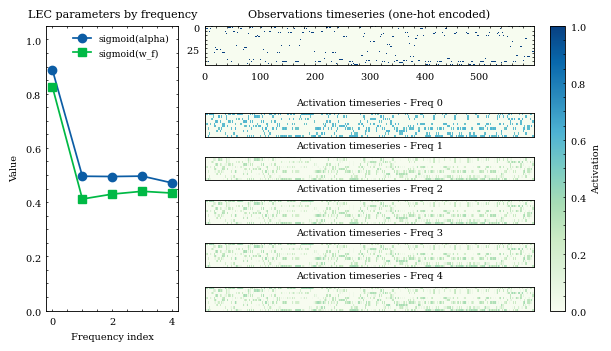

In [16]:
render("lec_summary", trace, FigureContext(env_idx=ENV_IDX))

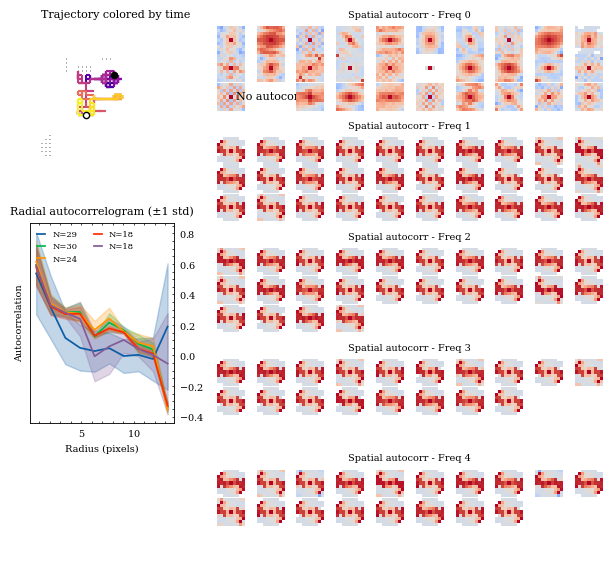

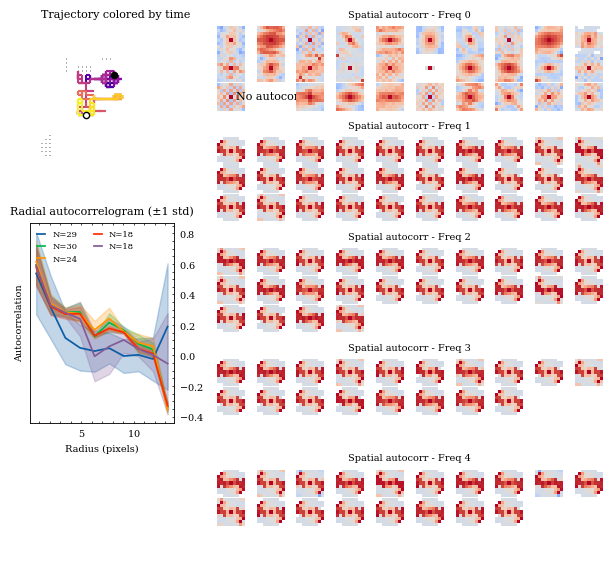

In [12]:
render("mec_summary", trace, FigureContext(env_idx=ENV_IDX))

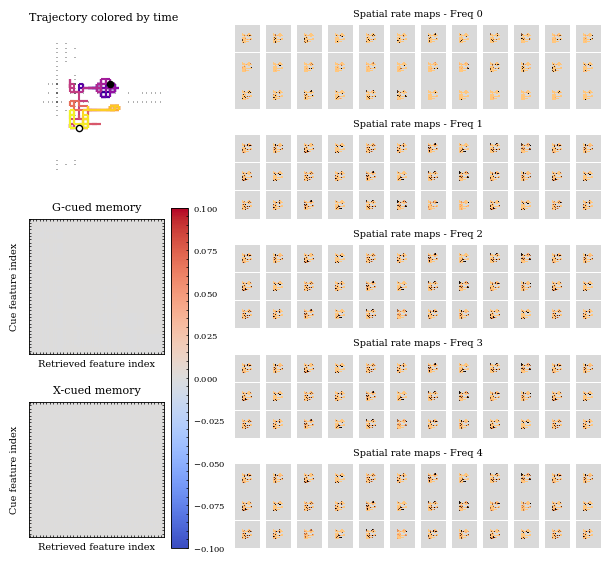

In [13]:
render("hpc_summary", trace, FigureContext(env_idx=ENV_IDX, freq_idx=FREQ_IDX))